## Lab assignment 02

### Neural Machine Translation in the wild
In the third homework you are supposed to get the best translation you can for the RU-EN translation task.

Basic approach using RNNs as encoder and decoder is implemented for you.

Your ultimate task is to use the techniques we've covered, e.g.

* Optimization enhancements (e.g. learning rate decay)

* Transformer/CNN/<whatever you select> encoder (with or without positional encoding)

* attention/self-attention mechanism (**highly recommended**)

* custom tokenization (BPE units, other subword approaches)

to improve the translation quality.

--------

* __Please use at least three different approaches/models and compare them (translation quality/complexity/training and evaluation time).__

* Write down some summary on your experiments and illustrate it with convergence plots/metrics and your thoughts. Just like you would approach a real problem.

In [1]:
# You might need to install the libraries below. Do it in the desired environment
# if you are working locally.

! pip  install subword-nmt
! pip install nltk


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Thanks to YSDA NLP course team for the data
# (who thanks tilda and deephack teams for the data in their turn)

import os
DATASET_FPATH = 'data.txt'
if not os.path.isfile(DATASET_FPATH):
    print("Dataset not found locally. Downloading from github.")
    # !wget https://raw.githubusercontent.com/neychev/made_nlp_course/master/datasets/Machine_translation_EN_RU/data.txt -nc
    !curl -O https://raw.githubusercontent.com/neychev/made_nlp_course/master/datasets/Machine_translation_EN_RU/data.txt
    DATASET_FPATH = 'data.txt'
else:
    print("Dataset found.")

Dataset found.


#### Grading criteria

**100%**
- implementation of at least 3 model improvements over baseline
- threshold of 27 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**70%**
- implementation of at least 2 model improvements over baseline
- threshold of 25 BLEU on test corpus
- experimental results and conclusions in human-readable format :)

**30%**
- implementation of at least 1 model improvement over baseline
- threshold of 21 BLEU on test corpus
- experimental results and conclusions in human-readable format :)


------

#### **Note: Please do not use pretrained machine translation / BERT / LLM checkpoints. All such solutions will be graded at 30% pts.**


### Warning! The code below is deeeeeeeply deprecated and is is provided only as simple guide.
We suggest you to stick to most recent pipelines here, e.g. by Huggingface:
* Example notebook: [link](https://github.com/huggingface/notebooks/blob/main/examples/translation.ipynb)
* Converting your own dataset to specific format: [link](https://discuss.huggingface.co/t/correct-way-to-create-a-dataset-from-a-csv-file/15686/15)

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

import random
import math
import time

import matplotlib
matplotlib.rcParams.update({'figure.figsize': (16, 12), 'font.size': 14})
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import clear_output

from nltk.tokenize import WordPunctTokenizer
from subword_nmt.learn_bpe import learn_bpe
from subword_nmt.apply_bpe import BPE


In [4]:
! pip install transformers


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import datasets
from transformers import AutoTokenizer
from datasets import load_dataset

In [6]:
import gc

In [7]:
def clean_memory():
    if 'model' in locals():
        model.to('cpu')
        del model
    gc.collect()
    torch.cuda.empty_cache()
    return

In [8]:
"""
Hugging Face translation dataset formatting:
 {'id': '90560',  //optional
 'translation': {'en': 'But this lofty plateau measured only a few fathoms, and soon we reentered Our Element.',
  'fr': 'Mais ce plateau élevé ne mesurait que quelques toises, et bientôt nous fûmes rentrés dans notre élément.'}}
"""

"\nHugging Face translation dataset formatting:\n {'id': '90560',  //optional\n 'translation': {'en': 'But this lofty plateau measured only a few fathoms, and soon we reentered Our Element.',\n  'fr': 'Mais ce plateau élevé ne mesurait que quelques toises, et bientôt nous fûmes rentrés dans notre élément.'}}\n"

In [9]:
def txt2dataset(fpath):
    with open(fpath, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    data = {"translation": []}
    for line in lines:
        # print(line)
        line_en, line_ru = line.strip().split('\t')
        data["translation"].append({"en":line_en, "ru": line_ru})
    return datasets.Dataset.from_dict(data)

In [10]:
my_dataset = txt2dataset(fpath=DATASET_FPATH)

In [11]:
my_dataset.info

DatasetInfo(description='', citation='', homepage='', license='', features={'translation': {'en': Value('string'), 'ru': Value('string')}}, post_processed=None, supervised_keys=None, builder_name=None, dataset_name=None, config_name=None, version=None, splits=None, download_checksums=None, download_size=None, post_processing_size=None, dataset_size=None, size_in_bytes=None)

In [12]:
print(my_dataset[0])

{'translation': {'en': 'Cordelia Hotel is situated in Tbilisi, a 3-minute walk away from Saint Trinity Church.', 'ru': 'Отель Cordelia расположен в Тбилиси, в 3 минутах ходьбы от Свято-Троицкого собора.'}}


### Main part
__Here comes the preprocessing. Do not hesitate to use BPE or more complex preprocessing ;)__

#### Reference code

In [13]:
# tokenizer_W = WordPunctTokenizer()
# def tokenize(x, tokenizer=tokenizer_W):
#     return tokenizer.tokenize(x.lower())

In [14]:
# SRC = Field(tokenize=tokenize,
#             init_token = '<sos>',
#             eos_token = '<eos>',
#             lower = True)

# TRG = Field(tokenize=tokenize,
#             init_token = '<sos>',
#             eos_token = '<eos>',
#             lower = True)

# dataset = torchtext.data.TabularDataset(
#     path=path_do_data,
#     format='tsv',
#     fields=[('trg', TRG), ('src', SRC)]
# )

In [ ]:
# train_data, valid_data, test_data = dataset.split(split_ratio=[0.8, 0.15, 0.05])

In [ ]:
# print(f"Number of training examples: {len(train_data.examples)}")
# print(f"Number of validation examples: {len(valid_data.examples)}")
# print(f"Number of testing examples: {len(test_data.examples)}")

Number of training examples: 40000
Number of validation examples: 2500
Number of testing examples: 7500


In [ ]:
# SRC.build_vocab(train_data, min_freq = 3)
# TRG.build_vocab(train_data, min_freq = 3)

In [ ]:
# print(f"Unique tokens in source (ru) vocabulary: {len(SRC.vocab)}")
# print(f"Unique tokens in target (en) vocabulary: {len(TRG.vocab)}")

Unique tokens in source (ru) vocabulary: 9267
Unique tokens in target (en) vocabulary: 6699


Here are tokens from original (RU) corpus:

In [ ]:
# SRC.vocab.itos[::1000]

['<unk>',
 '29',
 'соль',
 'комо',
 '―',
 'электрическая',
 'ming',
 'утренний',
 'детском',
 'таунус']

And from target (EN) corpus:

In [ ]:
# TRG.vocab.itos[::1000]

['<unk>', 'king', 'buffets', 'catch', 'media', 'schedule', 'maraunenhof']

And here is example from train dataset:

In [ ]:
# print(vars(train_data.examples[9]))

{'trg': ['laundry', 'service', 'is', 'provided', '.'], 'src': ['помимо', 'этого', ',', 'гостям', 'предоставляются', 'услуги', 'прачечной', '.']}


Let's check the length distributions:

Length distribution in Train data


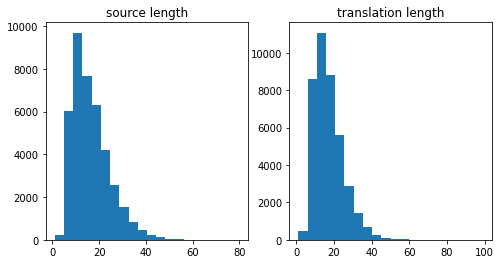

In [ ]:
# src_length = map(len, [vars(x)['src'] for x in train_data.examples])
# trg_length = map(len, [vars(x)['trg'] for x in train_data.examples])

# print('Length distribution in Train data')
# plt.figure(figsize=[8, 4])
# plt.subplot(1, 2, 1)
# plt.title("source length")
# plt.hist(list(src_length), bins=20);

# plt.subplot(1, 2, 2)
# plt.title("translation length")
# plt.hist(list(trg_length), bins=20);

Length distribution in Test data


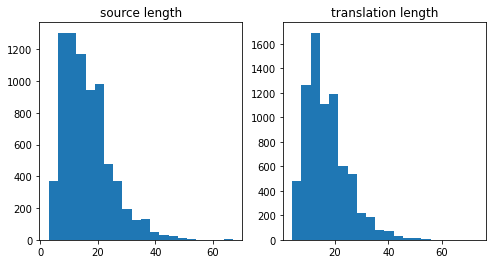

In [ ]:
# src_length = map(len, [vars(x)['src'] for x in test_data.examples])
# trg_length = map(len, [vars(x)['trg'] for x in test_data.examples])

# print('Length distribution in Test data')
# plt.figure(figsize=[8, 4])
# plt.subplot(1, 2, 1)
# plt.title("source length")
# plt.hist(list(src_length), bins=20);

# plt.subplot(1, 2, 2)
# plt.title("translation length")
# plt.hist(list(trg_length), bins=20);

#### My implementation

In [13]:
# Train, validation, test split [0.8, 0.15, 0.05]

data1 = my_dataset.train_test_split(test_size=0.20, seed=42)
data2 = data1['test'].train_test_split(test_size=(1 - 0.15 / 0.2), seed=42)
my_dataset = datasets.DatasetDict({
    'train': data1['train'],
    'validation': data2['train'],
    'test': data2['test'],
})

In [14]:
print(f"Train/val/test len: {[len(my_dataset[f]) for f in my_dataset.keys()]}")
print(f"Number of training examples: {len(my_dataset['train'])}")
print(f"Number of validation examples: {len(my_dataset['validation'])}")
print(f"Number of testing examples: {len(my_dataset['test'])}")

Train/val/test len: [40000, 7499, 2501]
Number of training examples: 40000
Number of validation examples: 7499
Number of testing examples: 2501


In [15]:
print(my_dataset.map)

<bound method DatasetDict.map of DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 40000
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 7499
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 2501
    })
})>


### Model side
__Here comes simple pipeline of NMT model learning. It almost copies the week02 practice__

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [17]:
import json
import os

def save_config(config, fpath):
    
    dirname = os.path.dirname(fpath)
    if dirname:
        os.makedirs(dirname, exist_ok=True)
    
    with open(fpath, 'w', encoding='utf-8') as f:
        json.dump(config, f, indent=4, ensure_ascii=False)
        
    print(f"Configuration saved to {fpath}")
    return

def load_config(fpath):
    with open(fpath, 'r', encoding='utf-8') as f:
        config = json.load(f)
    
    print(f"Configuration loaded from {fpath}")
    return config



---



#### Train/test functions

In [18]:
def train(model, iterator, optimizer, criterion, clip, train_history=None, valid_history=None):
    model.train()

    epoch_loss = 0
    history = []
    for i, batch in enumerate(iterator):

        src = batch['input_ids'].transpose(0, 1).to(device)
        trg = batch['labels'].transpose(0, 1).to(device)

        # src = batch[0].to(device)
        # trg = batch[1].to(device)

        optimizer.zero_grad()

        output = model(src, trg)

        output = output[1:].reshape(-1, output.shape[-1])
        trg = trg[1:].reshape(-1)

        loss = criterion(output, trg)

        loss.backward()

        # Let's clip the gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item()

        history.append(loss.cpu().data.numpy())
        if (i+1)%10==0:
            fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

            clear_output(True)
            ax[0].plot(history, label='train loss')
            ax[0].set_xlabel('Batch')
            ax[0].set_title(f'Train loss: epoch {str(len(valid_history) if valid_history is not None else 0)}')
            if train_history is not None:
                ax[1].plot(train_history, label='general train history')
                ax[1].set_xlabel('Epoch')
            if valid_history is not None:
                ax[1].plot(valid_history, label='general valid history')
            plt.legend()

            plt.show()


    return epoch_loss / len(iterator)

In [19]:
def evaluate(model, iterator, criterion):

    model.eval()

    epoch_loss = 0

    history = []

    with torch.no_grad():

        for i, batch in enumerate(iterator):

            src = batch['input_ids'].transpose(0, 1).to(device) # Transpose to [seq_len, batch_size]
            trg = batch['labels'].transpose(0, 1).to(device) # Transpose to [seq_len, batch_size]

            # src = batch[0].to(device)
            # trg = batch[1].to(device)

            output = model(src, trg, 0) #turn off teacher forcing

            #trg = [trg sent len, batch size]
            #output = [trg sent len, batch size, output dim]

            output = output[1:].reshape(-1, output.shape[-1])
            trg = trg[1:].reshape(-1)

            #trg = [(trg sent len - 1) * batch size]
            #output = [(trg sent len - 1) * batch size, output dim]

            loss = criterion(output, trg)

            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

In [20]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [21]:
def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param, -0.08, 0.08)

In [22]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [23]:
from nltk.translate.bleu_score import corpus_bleu
import numpy as np
import tqdm
import torch


def remove_tech_tokens(text, tokenizer):
    # Remove special tokens added by the tokenizer
    tokens_to_remove = set(tokenizer.all_special_ids)
    return [token for token in text if tokenizer.convert_tokens_to_ids(token) not in tokens_to_remove]

def decode_without_special_tokens(sp, ids):
    special_ids = {
        sp.pad_id(),
        sp.bos_id(),
        sp.eos_id(),
        sp.unk_id(),
    }
    ids = [i for i in ids if i not in special_ids] # and i != 15884]
    # print(ids)
    return sp.decode(ids)


def get_text(tokens, tokenizer):
    if isinstance(tokens, torch.Tensor):
        tokens = tokens.tolist()
    elif isinstance(tokens, np.ndarray):
        tokens = tokens.tolist()

    # ------------------- HuggingFace Tokenizer -------------------
    if hasattr(tokenizer, 'decode') and hasattr(tokenizer, 'eos_token_id'):
        filtered = [tid for tid in tokens
                    if tid not in (tokenizer.pad_token_id,
                                   tokenizer.eos_token_id,
                                   tokenizer.bos_token_id)]

        return tokenizer.decode(filtered, skip_special_tokens=True)

    # ------------------- sentencepiece -------------------
    else:
        special_ids = {0}

        if hasattr(tokenizer, 'bos_id') and tokenizer.bos_id() is not None:
            special_ids.add(tokenizer.bos_id())
        if hasattr(tokenizer, 'eos_id') and tokenizer.eos_id() is not None:
            special_ids.add(tokenizer.eos_id())
        if hasattr(tokenizer, 'unk_id') and tokenizer.unk_id() is not None:
            special_ids.add(tokenizer.unk_id())

        filtered = [tid for tid in tokens if tid not in special_ids]

        return tokenizer.decode(filtered)

In [24]:
def generate_translation(src, trg, model, tokenizer, device, inverse_src=False):
    model.eval()
    
    if hasattr(tokenizer, 'bos_token_id') and tokenizer.bos_token_id is not None:
        BOS_TOKEN = tokenizer.bos_token_id
    elif hasattr(tokenizer, 'bos_id'):
        BOS_TOKEN = tokenizer.bos_id()
    
    if hasattr(tokenizer, 'eos_token_id') and tokenizer.eos_token_id is not None:
        EOS_TOKEN = tokenizer.eos_token_id
    elif hasattr(tokenizer, 'eos_id'):
        EOS_TOKEN = tokenizer.eos_id()
    
    if inverse_src:
        src = src.flip(dims=[0])
    
    src_len = src.shape[0]
    
    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src.to(device))
    
    input_token = torch.tensor([BOS_TOKEN], device=device)
    output_tokens = []
    
    for _ in range(src_len * 2):
        with torch.no_grad():
            output, hidden, cell = model.decoder(input_token, hidden, cell, encoder_outputs)
        
        pred_token_id = output.argmax(1).item()
        
        if pred_token_id == EOS_TOKEN:
            break
            
        output_tokens.append(pred_token_id)
        input_token = torch.tensor([pred_token_id], device=device)
    
    original_tokens = src.squeeze(1).tolist()
    target_tokens = trg.squeeze(1).tolist()
    
    print(f"Original: {get_text(original_tokens, tokenizer)}")
    print(f"Target: {get_text(target_tokens, tokenizer)}")
    print(f"Generated: {get_text(output_tokens, tokenizer)}")
    
    return

In [25]:
def test_model(model, test_iterator, tokenizer, device, inverse_src=False):
    model.eval()
    
    print("=====Translation test=====")
    batch = next(iter(test_iterator))
    for idx in range(min(2, batch['input_ids'].shape[0])):
        src_example = batch['input_ids'][idx].unsqueeze(1)
        trg_example = batch['labels'][idx].unsqueeze(1)
        generate_translation(src_example, trg_example, model=model, tokenizer=tokenizer, device=device, inverse_src=inverse_src)
    print("==========================")
    
    original_text = []
    generated_text = []
    
    with torch.no_grad():
        for i, batch in enumerate(tqdm.tqdm(test_iterator)):
            src = batch['input_ids'].to(device)
            trg = batch['labels'].to(device)
            
            src = src.transpose(0, 1)
            trg = trg.transpose(0, 1)
            
            output = model(src, trg, 0)
            output = output.argmax(dim=-1)
            
            for j in range(output.shape[1]):
                gen_tokens = output[1:, j].cpu().tolist()
                ref_tokens = trg[1:, j].cpu().tolist()
                
                original_text.append(get_text(ref_tokens, tokenizer))
                generated_text.append(get_text(gen_tokens, tokenizer))

    bleu = corpus_bleu([[text] for text in original_text], generated_text) * 100

    print(f"BLEU= {bleu:.2f}")
    
    return bleu

#### Cuda memory clean-up

In [26]:
clean_memory()
print(torch.cuda.memory_summary())

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |

### Experiment 1

##### Tokenizer

Helsinki-NLP/opus-mt-ru-en:
Training Data
*   Pre-processing: Normalization + SentencePiece
*   Dataset: opus

Приведение к нижнему регистру не делается.

Результат:
-> слишком большой размер словаря

-> слишком долго обучается

In [27]:
# Pre-trained tokenizer (reference: https://discuss.huggingface.co/t/correct-way-to-create-a-dataset-from-a-csv-file/15686/15)

tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-ru-en")
source_lang = "ru"
target_lang = "en"
prefix = "translate Russian to English: "

X:\repos\venvs\adv_ml\Lib\site-packages\transformers\models\marian\tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


In [28]:
print(tokenizer)

MarianTokenizer(name_or_path='Helsinki-NLP/opus-mt-ru-en', vocab_size=62518, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>'}, added_tokens_decoder={
	0: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	62517: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})


In [29]:
txt_sample = r"Отель Cordelia расположен в Тбилиси, в 3 минутах ходьбы от Свято-Троицкого собора."

In [30]:
tokenizer.tokenize(txt_sample)[:10]

['▁От', 'ель', '▁C', 'ord', 'el', 'ia', '▁расположен', '▁в', '▁Тбилиси', ',']

In [31]:
special_tokens_dict = {
    'bos_token': '<bos>',
    'eos_token': '<eos>',
    'pad_token': '<pad>',
    'unk_token': '<unk>'   
}

tokenizer.add_special_tokens(special_tokens_dict)

2

In [32]:
def preprocess_function(examples, max_length=128, source_lang="ru", target_lang="en", inverse_src=False):
    inputs = [f[source_lang] for f in examples["translation"]]
    targets = [f[target_lang] for f in examples["translation"]]

    model_inputs = {"input_ids": [], "labels": []}
    
    bos_id = tokenizer.bos_token_id
    eos_id = tokenizer.eos_token_id
    pad_id = tokenizer.pad_token_id

    for i in range(len(inputs)):
        input_ids = tokenizer.encode(inputs[i], add_special_tokens=False)
        if inverse_src:
            input_ids = input_ids[::-1]
        input_ids_with_special = [bos_id] + input_ids + [eos_id]
        
        if len(input_ids_with_special) > max_length:
            input_ids_with_special = input_ids_with_special[:max_length]
        else:
            input_ids_with_special = input_ids_with_special + [pad_id] * (max_length - len(input_ids_with_special))
        model_inputs["input_ids"].append(input_ids_with_special)
        
        label_ids = tokenizer.encode(targets[i], add_special_tokens=False)
        label_ids_with_special = [bos_id] + label_ids + [eos_id]
        
        if len(label_ids_with_special) > max_length:
            label_ids_with_special = label_ids_with_special[:max_length]
        else:
            label_ids_with_special = label_ids_with_special + [pad_id] * (max_length - len(label_ids_with_special))       

        model_inputs["labels"].append(label_ids_with_special)

    return model_inputs

In [33]:
tokenized_dataset = my_dataset.map(preprocess_function, batched=True, remove_columns=my_dataset["train"].column_names)

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7499 [00:00<?, ? examples/s]

Map:   0%|          | 0/2501 [00:00<?, ? examples/s]

Length distribution in Train data


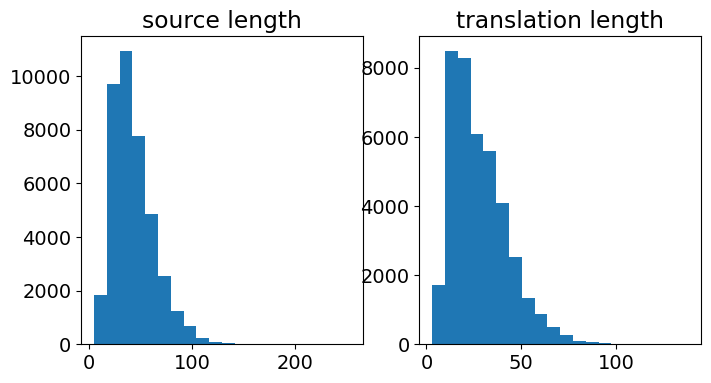

In [34]:
src_length = map(len, [tokenizer.tokenize(f['translation']['en']) for f in my_dataset["train"]])
trg_length = map(len, [tokenizer.tokenize(f['translation']['ru']) for f in my_dataset["train"]])

print('Length distribution in Train data')
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(src_length), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(trg_length), bins=20);

Length distribution in Test data


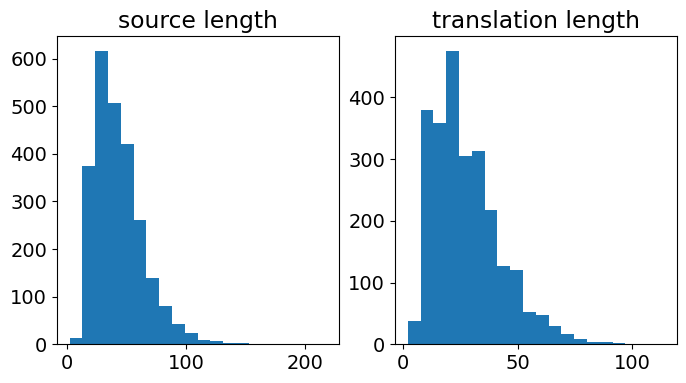

In [35]:
src_length = map(len, [tokenizer.tokenize(f['translation']['en']) for f in my_dataset["test"]])
trg_length = map(len, [tokenizer.tokenize(f['translation']['ru']) for f in my_dataset["test"]])

print('Length distribution in Test data')
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(src_length), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(trg_length), bins=20);

##### Dataloader

In [36]:
from torch.utils.data import DataLoader

In [37]:
def data_collator(batch):
    input_ids = torch.tensor([item['input_ids'] for item in batch], dtype=torch.long)
    labels = torch.tensor([item['labels'] for item in batch], dtype=torch.long)
    return {
        'input_ids': input_ids,
        'labels': labels
    }

In [38]:
BATCH_SIZE = 64  # 128

train_dataloader = DataLoader(
    tokenized_dataset["train"],
    shuffle=True,
    batch_size=BATCH_SIZE,
    collate_fn=data_collator
)
valid_dataloader = DataLoader(
    tokenized_dataset["validation"],
    shuffle=False,
    batch_size=BATCH_SIZE,
    collate_fn=data_collator
)
test_dataloader = DataLoader(
    tokenized_dataset["test"],
    shuffle=False,
    batch_size=BATCH_SIZE,
    collate_fn=data_collator
)

In [39]:
for batch_idx, batch_data in enumerate(train_dataloader):
    print(f"Batch {batch_idx}: Input IDs shape {batch_data['input_ids'].shape}, Labels shape {batch_data['labels'].shape}")
    break

Batch 0: Input IDs shape torch.Size([64, 128]), Labels shape torch.Size([64, 128])


##### Model (base)

Базовые версии из файла my_network.py

In [40]:
clean_memory()

In [41]:
from my_network import Encoder, Decoder, Seq2Seq

In [42]:
config = {
    "BATCH_SIZE": BATCH_SIZE,
    "INPUT_DIM": len(tokenizer),
    "OUTPUT_DIM": len(tokenizer),
    "ENC_EMB_DIM": 256,  # 256
    "DEC_EMB_DIM": 256,  # 256
    "HID_DIM": 512,      # 512
    "N_LAYERS": 2,
    "ENC_DROPOUT": 0.3,
    "DEC_DROPOUT": 0.3,
    "PAD_IDX": tokenizer.pad_token_id,
    
    # optimizer
    "LR": 1e-3,
    "WEIGHT_DECAY": 1e-5, #1e-4

    # scheduler
    "STEP_SIZE": 4,
    "GAMMA": 0.5,
}
print(config)

{'BATCH_SIZE': 64, 'INPUT_DIM': 62520, 'OUTPUT_DIM': 62520, 'ENC_EMB_DIM': 256, 'DEC_EMB_DIM': 256, 'HID_DIM': 512, 'N_LAYERS': 2, 'ENC_DROPOUT': 0.3, 'DEC_DROPOUT': 0.3, 'PAD_IDX': 62517, 'LR': 0.001, 'WEIGHT_DECAY': 1e-05, 'STEP_SIZE': 4, 'GAMMA': 0.5}


In [43]:
enc = Encoder(
    input_dim=config["INPUT_DIM"],
    emb_dim=config["ENC_EMB_DIM"],
    hid_dim=config["HID_DIM"],
    n_layers=config["N_LAYERS"],
    dropout=config["ENC_DROPOUT"],
    pad_idx=config["PAD_IDX"],
)

dec = Decoder(
    output_dim=config["OUTPUT_DIM"],
    emb_dim=config["DEC_EMB_DIM"],
    hid_dim=config["HID_DIM"],
    n_layers=config["N_LAYERS"],
    dropout=config["DEC_DROPOUT"],
    pad_idx=config["PAD_IDX"],
)

# dont forget to put the model to the right device
model = Seq2Seq(enc, dec, device).to(device)

In [44]:
model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(62520, 256, padding_idx=62517)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.3)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(62520, 256, padding_idx=62517)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.3)
    (out): Linear(in_features=512, out_features=62520, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

In [45]:
print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 71,439,416 trainable parameters


In [46]:
print("PAD_IDX=", config["PAD_IDX"])
optimizer = optim.Adam(
    model.parameters(),
    lr=config["LR"],
    weight_decay=config["WEIGHT_DECAY"]
)
criterion = nn.CrossEntropyLoss(
    ignore_index=config["PAD_IDX"]
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=config["STEP_SIZE"],
    gamma=config["GAMMA"]
)
save_config(config=config, fpath="experiment1.json")

PAD_IDX= 62517
Configuration saved to experiment1.json


##### Train

In [47]:
train_history = []
valid_history = []

N_EPOCHS = 5
CLIP = 1
# CLIP = 0.5
best_valid_loss = float('inf')

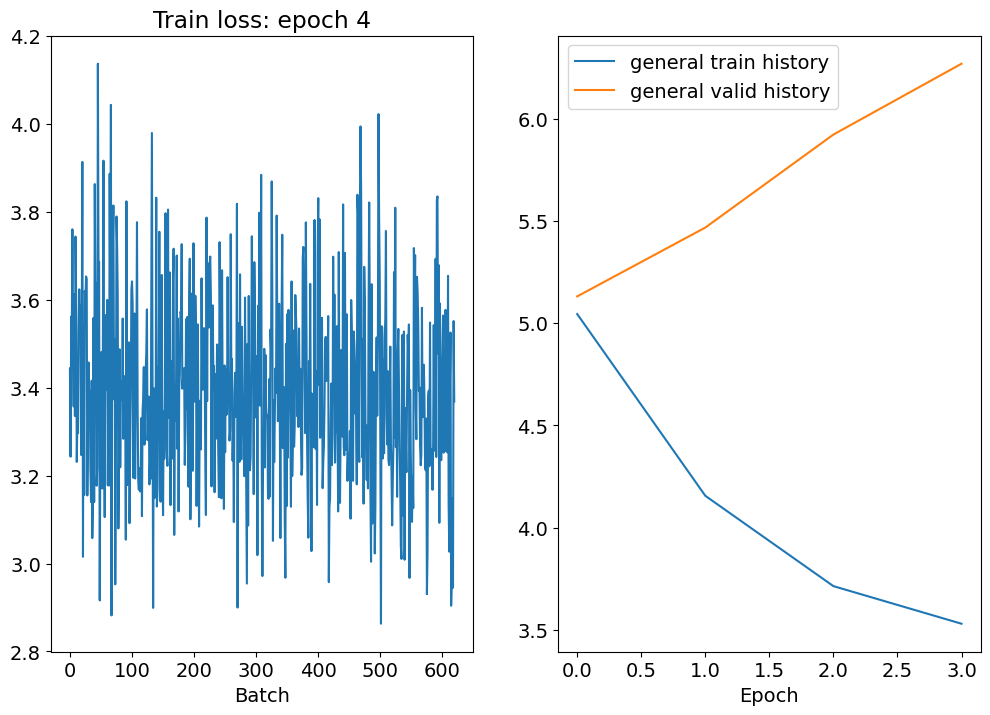

Epoch: 05 | Time: 14m 36s
	Train Loss: 3.395 | Train PPL:  29.801
	 Val. Loss: 6.645 |  Val. PPL: 768.660
{'BATCH_SIZE': 64, 'INPUT_DIM': 62520, 'OUTPUT_DIM': 62520, 'ENC_EMB_DIM': 256, 'DEC_EMB_DIM': 256, 'HID_DIM': 512, 'N_LAYERS': 2, 'ENC_DROPOUT': 0.3, 'DEC_DROPOUT': 0.3, 'PAD_IDX': 62517, 'LR': 0.001, 'WEIGHT_DECAY': 1e-05, 'STEP_SIZE': 4, 'GAMMA': 0.5}


In [48]:
for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss = train(model, train_dataloader, optimizer, criterion, CLIP, train_history, valid_history)
    valid_loss = evaluate(model, valid_dataloader, criterion)

    scheduler.step()

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'experiment1_model.pt')

    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

print(config)

##### Test

###### Reload model if needed

In [109]:
clean_memory()

In [110]:
import importlib
import my_network
importlib.reload(my_network)
from my_network import Encoder, Decoder, Seq2Seq

In [111]:
config = load_config(fpath="experiment1.json")
enc = Encoder(
    input_dim=config["INPUT_DIM"],
    emb_dim=config["ENC_EMB_DIM"],
    hid_dim=config["HID_DIM"],
    n_layers=config["N_LAYERS"],
    dropout=config["ENC_DROPOUT"],
    pad_idx=config["PAD_IDX"],
)

dec = Decoder(
    output_dim=config["OUTPUT_DIM"],
    emb_dim=config["DEC_EMB_DIM"],
    hid_dim=config["HID_DIM"],
    n_layers=config["N_LAYERS"],
    dropout=config["DEC_DROPOUT"],
    pad_idx=config["PAD_IDX"],
)

model = Seq2Seq(enc, dec, device).to(device)
state_dict = torch.load('experiment1_model.pt', weights_only=True)
model.load_state_dict(state_dict)
model.eval()

Configuration loaded from experiment1.json


Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(62520, 256, padding_idx=62517)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.3)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(62520, 256, padding_idx=62517)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.3)
    (out): Linear(in_features=512, out_features=62520, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

In [49]:
test_model(model, test_iterator=test_dataloader, tokenizer=tokenizer, device=device)

=====Translation test=====
Original: Предоставляется постельное белье.
Target: Extras include bed linen and towels.
Generated: There is a private bathroom with a shower.
Original: Гости могут посетить ресторан гостевого дома, в котором подаются блюда восточной кухни.
Target: Guests are welcome to visit the on-site restaurant and taste Eastern cuisine.
Generated: There is a private bathroom with a shower.


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:27<00:00,  1.45it/s]


BLEU= 8.37


8.373643965321408

##### Experiment 1 with inverted src

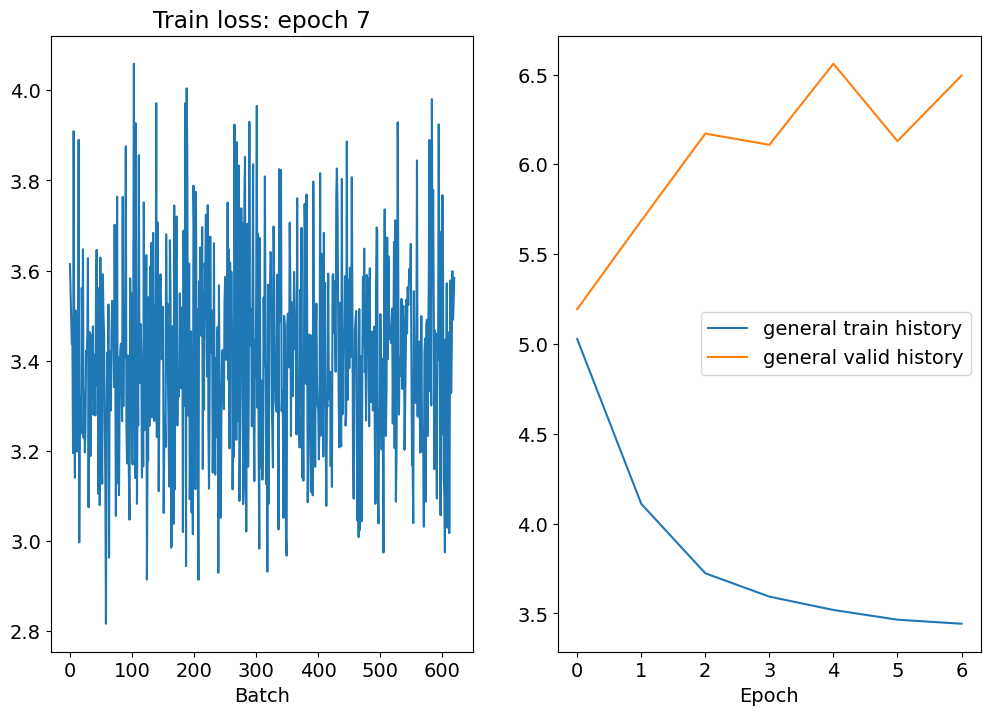

Epoch: 08 | Time: 14m 25s
	Train Loss: 3.408 | Train PPL:  30.190
	 Val. Loss: 6.655 |  Val. PPL: 776.653
{'BATCH_SIZE': 64, 'INPUT_DIM': 62520, 'OUTPUT_DIM': 62520, 'ENC_EMB_DIM': 256, 'DEC_EMB_DIM': 256, 'HID_DIM': 512, 'N_LAYERS': 2, 'ENC_DROPOUT': 0.3, 'DEC_DROPOUT': 0.3, 'PAD_IDX': 62517, 'LR': 0.001, 'WEIGHT_DECAY': 1e-05, 'STEP_SIZE': 2, 'GAMMA': 0.5}


In [48]:
# for epoch in range(N_EPOCHS):

#     start_time = time.time()

#     train_loss = train(model, train_dataloader, optimizer, criterion, CLIP, train_history, valid_history)
#     valid_loss = evaluate(model, valid_dataloader, criterion)

#     scheduler.step()

#     end_time = time.time()

#     epoch_mins, epoch_secs = epoch_time(start_time, end_time)

#     if valid_loss < best_valid_loss:
#         best_valid_loss = valid_loss
#         torch.save(model.state_dict(), 'experiment1_model.pt')

#     train_history.append(train_loss)
#     valid_history.append(valid_loss)
#     print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
#     print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
#     print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

# print(config)

In [123]:
# test_model(model, test_iterator=test_dataloader, tokenizer=tokenizer, device=device, inverse_src=True)

=====Translation test=====
Original: Предоставляется постельное белье.
Target: Extras include bed linen and towels.
Generated: The es is                        .
Original: Гости могут посетить ресторан гостевого дома, в котором подаются блюда восточной кухни.
Target: Guests are welcome to visit the on-site restaurant and taste Eastern cuisine.
Generated: The es is                        .


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:25<00:00,  1.55it/s]


BLEU= 4.17


4.168023167414712

##### Lucky experiment 1 with direct scr

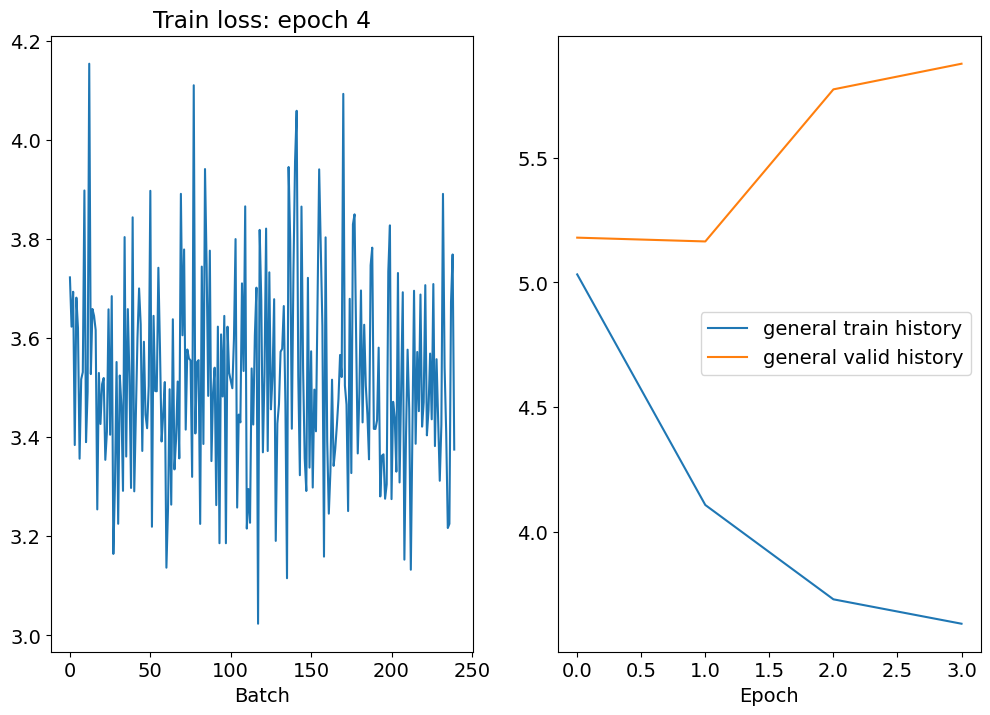

KeyboardInterrupt: 

In [67]:
for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss = train(model, train_dataloader, optimizer, criterion, CLIP, train_history, valid_history)
    valid_loss = evaluate(model, valid_dataloader, criterion)

    scheduler.step()

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'experiment1_model_try2.pt')

    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

print(config)

In [68]:
test_model(model, test_iterator=test_dataloader, tokenizer=tokenizer, device=device)

=====Translation test=====
Original: Предоставляется постельное белье.
Target: Extras include bed linen and towels.
Generated: There is a private bathroom with a shower.
Original: Гости могут посетить ресторан гостевого дома, в котором подаются блюда восточной кухни.
Target: Guests are welcome to visit the on-site restaurant and taste Eastern cuisine.
Generated: Theree  is  is a minutes drive from the property.


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:27<00:00,  1.43it/s]


BLEU= 15.39


15.392497258795993

### Experiment 2

In [50]:
try:
    del tokenizer
except:
    pass

##### Tokenizer

SentencePiece tokenizer

In [51]:
import sentencepiece as spm

spm.SentencePieceTrainer.train(
    input=DATASET_FPATH,
    model_prefix="spm",
    vocab_size=16000,
    model_type="bpe",

    pad_id=0,
    bos_id=1,
    eos_id=2,
    unk_id=3,

    pad_piece="<pad>",
    bos_piece="<s>",
    eos_piece="</s>",
    unk_piece="<unk>"
)
tokenizer = spm.SentencePieceProcessor()
tokenizer.load("spm.model")

True

In [52]:
tokenizer.encode(r"Отель Cordelia расположен в Тбилиси, в 3 минутах ходьбы от Свято-Троицкого собора.", out_type=str)[:10]

['▁Отель',
 '▁Cord',
 'elia',
 '▁расположен',
 '▁в',
 '▁Тбилиси',
 ',',
 '▁в',
 '▁3',
 '▁минутах']

In [53]:
PAD_IDX = tokenizer.pad_id()
PAD_IDX

0

In [76]:
def preprocess_function(examples, max_length=128, source_lang="ru", target_lang="en", inverse_src=False):
    inputs = [f[source_lang] for f in examples["translation"]]
    targets = [f[target_lang] for f in examples["translation"]]

    # model_inputs = {"input_ids": [], "attention_mask": []}
    model_inputs = {"input_ids": []}
    labels_list = []

    bos_id = tokenizer.bos_id()
    eos_id = tokenizer.eos_id()
    pad_id = tokenizer.pad_id()

    for i in range(len(inputs)):
        input_ids = tokenizer.encode_as_ids(inputs[i])
        if inverse_src:
            input_ids = input_ids[::-1] # # !!!
        input_ids_with_special = [bos_id] + input_ids + [eos_id]

        if len(input_ids_with_special) > max_length:
            input_ids_with_special = input_ids_with_special[:max_length]
        else:
            input_ids_with_special = input_ids_with_special + [pad_id] * (max_length - len(input_ids_with_special))
        model_inputs["input_ids"].append(input_ids_with_special)

        # attention_mask = [1] * min(len(input_ids) + 2, max_length)
        # attention_mask = attention_mask + [0] * (max_length - len(attention_mask))
        # model_inputs["attention_mask"].append(attention_mask)

        label_ids = tokenizer.encode_as_ids(targets[i])
        label_ids_with_special = [bos_id] + label_ids + [eos_id]

        if len(label_ids_with_special) > max_length:
            label_ids_with_special = label_ids_with_special[:max_length]
        else:
            label_ids_with_special = label_ids_with_special + [pad_id] * (max_length - len(label_ids_with_special))
        labels_list.append(label_ids_with_special)

    model_inputs["labels"] = labels_list

    return model_inputs

In [77]:
tokenized_dataset = my_dataset.map(preprocess_function, batched=True, remove_columns=my_dataset["train"].column_names)

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7499 [00:00<?, ? examples/s]

Map:   0%|          | 0/2501 [00:00<?, ? examples/s]

Length distribution in Train data


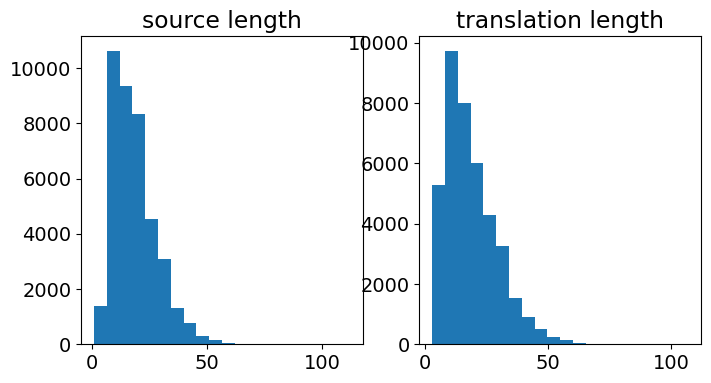

In [56]:
src_length = map(len, [tokenizer.tokenize(f['translation']['en']) for f in my_dataset["train"]])
trg_length = map(len, [tokenizer.tokenize(f['translation']['ru']) for f in my_dataset["train"]])

print('Length distribution in Train data')
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(src_length), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(trg_length), bins=20);

Length distribution in Test data


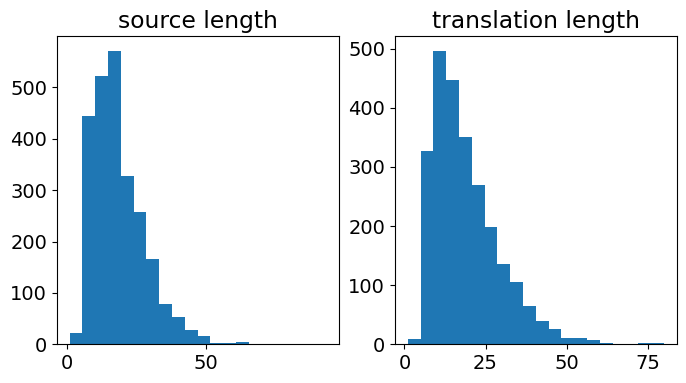

In [57]:
src_length = map(len, [tokenizer.tokenize(f['translation']['en']) for f in my_dataset["test"]])
trg_length = map(len, [tokenizer.tokenize(f['translation']['ru']) for f in my_dataset["test"]])

print('Length distribution in Test data')
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(src_length), bins=20);

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(trg_length), bins=20);

##### Config

In [78]:
config = {
    "BATCH_SIZE": 32,
    "INPUT_DIM": tokenizer.vocab_size(),
    "OUTPUT_DIM": tokenizer.vocab_size(),
    "ENC_EMB_DIM": 256,
    "DEC_EMB_DIM": 256,
    "HID_DIM": 512, 
    "N_LAYERS": 2,
    "ENC_DROPOUT": 0.3,
    "DEC_DROPOUT": 0.3,
    "PAD_IDX": tokenizer.pad_id(),

    # optimizer
    "LR": 1e-3,
    "WEIGHT_DECAY": 1e-5,

    # scheduler
    "STEP_SIZE": 4,
    "GAMMA": 0.5,
}
print(config)

{'BATCH_SIZE': 32, 'INPUT_DIM': 16000, 'OUTPUT_DIM': 16000, 'ENC_EMB_DIM': 256, 'DEC_EMB_DIM': 256, 'HID_DIM': 512, 'N_LAYERS': 2, 'ENC_DROPOUT': 0.3, 'DEC_DROPOUT': 0.3, 'PAD_IDX': 0, 'LR': 0.001, 'WEIGHT_DECAY': 1e-05, 'STEP_SIZE': 4, 'GAMMA': 0.5}


In [79]:
save_config(config, "experiment2.json")

Configuration saved to experiment2.json


In [80]:
config = load_config("experiment2.json")
print(config)

Configuration loaded from experiment2.json
{'BATCH_SIZE': 32, 'INPUT_DIM': 16000, 'OUTPUT_DIM': 16000, 'ENC_EMB_DIM': 256, 'DEC_EMB_DIM': 256, 'HID_DIM': 512, 'N_LAYERS': 2, 'ENC_DROPOUT': 0.3, 'DEC_DROPOUT': 0.3, 'PAD_IDX': 0, 'LR': 0.001, 'WEIGHT_DECAY': 1e-05, 'STEP_SIZE': 4, 'GAMMA': 0.5}


In [90]:
# {'BATCH_SIZE': 32, 'INPUT_DIM': 16000, 'OUTPUT_DIM': 16000, 'ENC_EMB_DIM': 256, 'DEC_EMB_DIM': 256, 'HID_DIM': 512, 'N_LAYERS': 2, 'ENC_DROPOUT': 0.3, 'DEC_DROPOUT': 0.3, 'PAD_IDX': 0, 'LR': 0.001, 'WEIGHT_DECAY': 1e-05, 'STEP_SIZE': 2, 'GAMMA': 0.5}

##### Dataloader

In [81]:
from torch.utils.data import DataLoader

In [82]:
def data_collator(batch):
    input_ids = torch.tensor([item['input_ids'] for item in batch], dtype=torch.long)
    # attention_mask = torch.tensor([item['attention_mask'] for item in batch], dtype=torch.long)
    labels = torch.tensor([item['labels'] for item in batch], dtype=torch.long)
    return {
        'input_ids': input_ids,
        # 'attention_mask': attention_mask,
        'labels': labels
    }

In [83]:
train_dataloader = DataLoader(
    tokenized_dataset["train"],
    shuffle=True,
    batch_size=config["BATCH_SIZE"],
    collate_fn=data_collator
)
valid_dataloader = DataLoader(
    tokenized_dataset["validation"],
    shuffle=False,
    batch_size=config["BATCH_SIZE"],
    collate_fn=data_collator
)
test_dataloader = DataLoader(
    tokenized_dataset["test"],
    shuffle=False,
    batch_size=config["BATCH_SIZE"],
    collate_fn=data_collator
)

##### Model (base)

Базовые версии из файла my_network.py

In [84]:
clean_memory()

In [85]:
import importlib
import my_network
importlib.reload(my_network)
from my_network import Encoder, Decoder, Seq2Seq

In [86]:
enc = Encoder(
    input_dim=config["INPUT_DIM"],
    emb_dim=config["ENC_EMB_DIM"],
    hid_dim=config["HID_DIM"],
    n_layers=config["N_LAYERS"],
    dropout=config["ENC_DROPOUT"],
    pad_idx=config["PAD_IDX"],
)
dec = Decoder(
    output_dim=config["OUTPUT_DIM"],
    emb_dim=config["DEC_EMB_DIM"],
    hid_dim=config["HID_DIM"],
    n_layers=config["N_LAYERS"],
    dropout=config["DEC_DROPOUT"],
    pad_idx=config["PAD_IDX"],
)

model = Seq2Seq(enc, dec, device).to(device)

In [87]:
model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(16000, 256, padding_idx=0)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.3)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(16000, 256, padding_idx=0)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.3)
    (out): Linear(in_features=512, out_features=16000, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

In [88]:
print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 23,756,416 trainable parameters


In [89]:
print("PAD_IDX=", tokenizer.pad_id())
optimizer = optim.Adam(
    model.parameters(),
    lr=config["LR"],
    weight_decay=config["WEIGHT_DECAY"]
)
criterion = nn.CrossEntropyLoss(
    ignore_index=config["PAD_IDX"]
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=config["STEP_SIZE"],
    gamma=config["GAMMA"]
)

PAD_IDX= 0


##### Train

In [90]:
train_history = []
valid_history = []

N_EPOCHS = 10
CLIP = 1

best_valid_loss = float('inf')

In [ ]:
# Experiment 2 with inverse_src=False

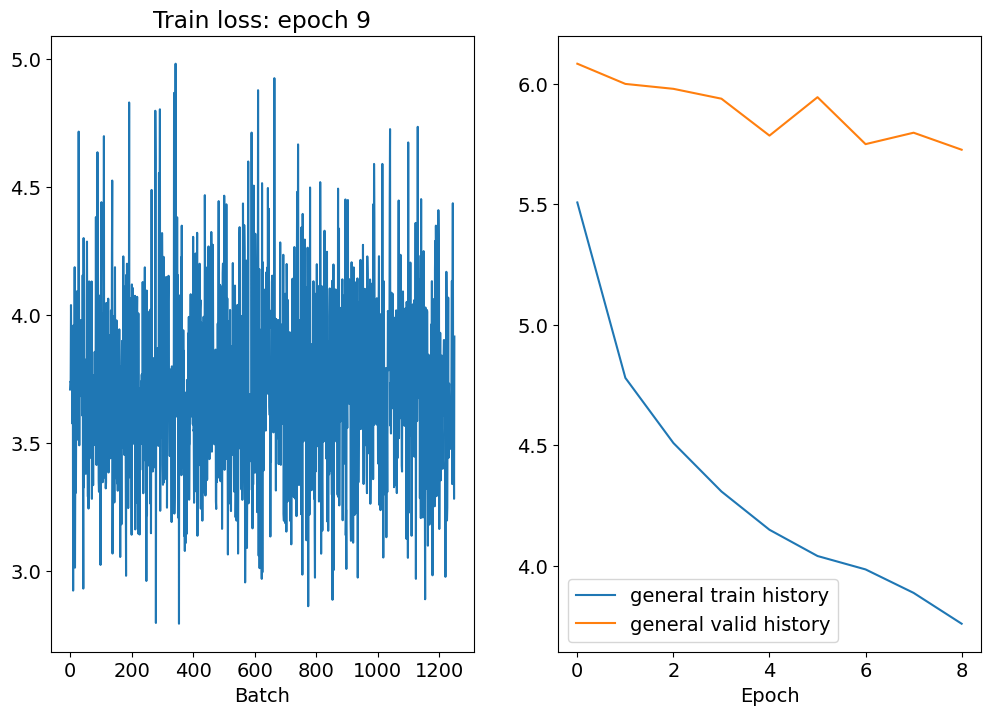

Epoch: 10 | Time: 5m 51s
	Train Loss: 3.728 | Train PPL:  41.607
	 Val. Loss: 5.690 |  Val. PPL: 295.800
{'BATCH_SIZE': 32, 'INPUT_DIM': 16000, 'OUTPUT_DIM': 16000, 'ENC_EMB_DIM': 256, 'DEC_EMB_DIM': 256, 'HID_DIM': 512, 'N_LAYERS': 2, 'ENC_DROPOUT': 0.3, 'DEC_DROPOUT': 0.3, 'PAD_IDX': 0, 'LR': 0.001, 'WEIGHT_DECAY': 1e-05, 'STEP_SIZE': 4, 'GAMMA': 0.5}


In [91]:
for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss = train(model, train_dataloader, optimizer, criterion, CLIP, train_history, valid_history)
    valid_loss = evaluate(model, valid_dataloader, criterion)

    scheduler.step()

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'experiment2_model_not_inv.pt')

    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

print(config)

##### Evaluation

In [ ]:
# config = load_config("experiment2.json")
# print(config)

In [139]:
# clean_memory()

# enc = Encoder(
#     input_dim=config["INPUT_DIM"],
#     emb_dim=config["ENC_EMB_DIM"],
#     hid_dim=config["HID_DIM"],
#     n_layers=config["N_LAYERS"],
#     dropout=config["ENC_DROPOUT"],
#     pad_idx=config["PAD_IDX"],
# )
# dec = Decoder(
#     output_dim=config["OUTPUT_DIM"],
#     emb_dim=config["DEC_EMB_DIM"],
#     hid_dim=config["HID_DIM"],
#     n_layers=config["N_LAYERS"],
#     dropout=config["DEC_DROPOUT"],
#     pad_idx=config["PAD_IDX"],
# )

# model = Seq2Seq(enc, dec, device).to(device)

In [140]:
# state_dict = torch.load('exp2_best_model.pt', weights_only=True)
# model.load_state_dict(state_dict)
# model.eval()

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(16000, 64, padding_idx=0)
    (rnn): LSTM(64, 128, num_layers=2, dropout=0.5)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(16000, 64)
    (rnn): LSTM(64, 128, num_layers=2, dropout=0.5)
    (out): Linear(in_features=128, out_features=16000, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

In [92]:
test_model(model, test_iterator=test_dataloader, tokenizer=tokenizer, device=device, inverse_src=False)

=====Translation test=====
Original: Предоставляется постельное белье.
Target: Extras include bed linen and towels.
Generated: Bed linen is available.
Original: Гости могут посетить ресторан гостевого дома, в котором подаются блюда восточной кухни.
Target: Guests are welcome to visit the on-site restaurant and taste Eastern cuisine.
Generated: The restaurant serves international cuisine and international cuisine.


100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:08<00:00,  9.76it/s]


BLEU= 35.66


35.655657284584535

##### Experiment 2 with inverse_src=True

Эксперимент с реверсированием входных данных дал результат хуже, чем с прямым порядком: 8.29 vs 35.66

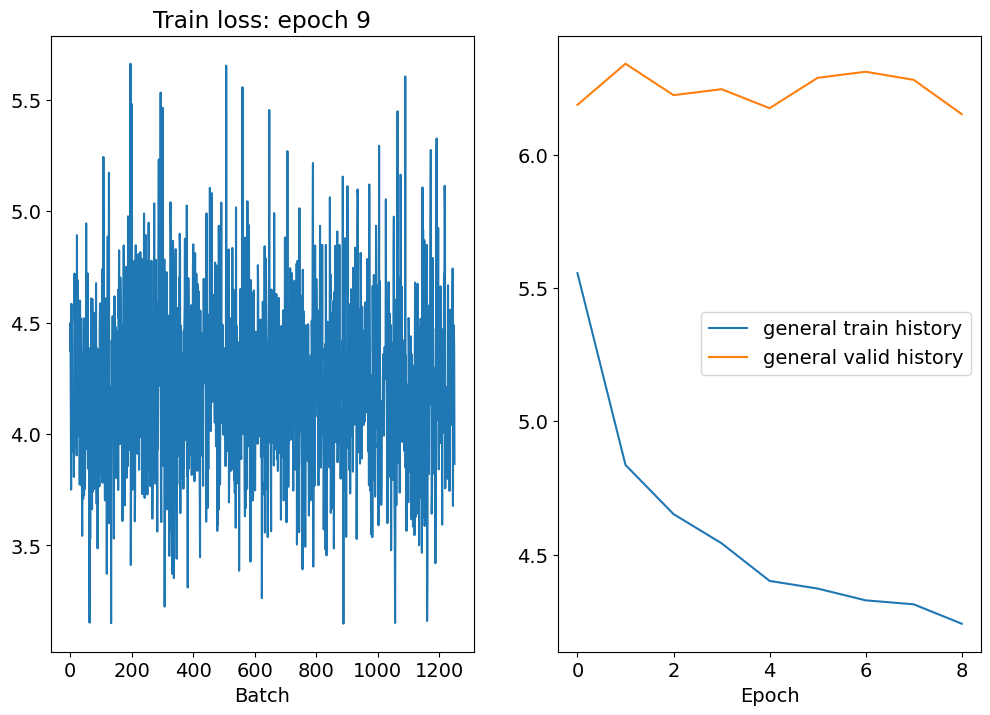

Epoch: 10 | Time: 5m 49s
	Train Loss: 4.212 | Train PPL:  67.504
	 Val. Loss: 6.138 |  Val. PPL: 463.145
{'BATCH_SIZE': 32, 'INPUT_DIM': 16000, 'OUTPUT_DIM': 16000, 'ENC_EMB_DIM': 256, 'DEC_EMB_DIM': 256, 'HID_DIM': 512, 'N_LAYERS': 2, 'ENC_DROPOUT': 0.3, 'DEC_DROPOUT': 0.3, 'PAD_IDX': 0, 'LR': 0.001, 'WEIGHT_DECAY': 1e-05, 'STEP_SIZE': 4, 'GAMMA': 0.5}


In [70]:
# for epoch in range(N_EPOCHS):

#     start_time = time.time()

#     train_loss = train(model, train_dataloader, optimizer, criterion, CLIP, train_history, valid_history)
#     valid_loss = evaluate(model, valid_dataloader, criterion)

#     scheduler.step()

#     end_time = time.time()

#     epoch_mins, epoch_secs = epoch_time(start_time, end_time)

#     if valid_loss < best_valid_loss:
#         best_valid_loss = valid_loss
#         torch.save(model.state_dict(), 'experiment2_model.pt')

#     train_history.append(train_loss)
#     valid_history.append(valid_loss)
#     print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
#     print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
#     print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

# print(config)

In [75]:
# test_model(model, test_iterator=test_dataloader, tokenizer=tokenizer, device=device, inverse_src=True)

=====Translation test=====
Original: Предоставляется постельное белье.
Target: Extras include bed linen and towels.
Generated: The is is a a and a.
Original: Гости могут посетить ресторан гостевого дома, в котором подаются блюда восточной кухни.
Target: Guests are welcome to visit the on-site restaurant and taste Eastern cuisine.
Generated: The is is a a and a.


100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:08<00:00,  9.76it/s]


BLEU= 8.29


8.294385835346278

### Experiment 3 (Improvements)

In [94]:
clean_memory()

##### Tokenizer

Reuse SentencePiece tokenizer from experiment 2

##### Dataloader

In [95]:
from torch.utils.data import DataLoader

In [96]:
def data_collator(batch):
    input_ids = torch.tensor([item['input_ids'] for item in batch], dtype=torch.long)
    labels = torch.tensor([item['labels'] for item in batch], dtype=torch.long)
    return {
        'input_ids': input_ids,
        'labels': labels
    }

In [97]:
BATCH_SIZE = 32 # 64  # 128

train_dataloader = DataLoader(
    tokenized_dataset["train"],
    shuffle=True,
    batch_size=BATCH_SIZE,
    collate_fn=data_collator
)
valid_dataloader = DataLoader(
    tokenized_dataset["validation"],
    shuffle=False,
    batch_size=BATCH_SIZE,
    collate_fn=data_collator
)
test_dataloader = DataLoader(
    tokenized_dataset["test"],
    shuffle=False,
    batch_size=BATCH_SIZE,
    collate_fn=data_collator
)

##### Model (with attention)

Добавляем Attention (референсная реализация https://docs.pytorch.org/tutorials/intermediate/seq2seq_translation_tutorial.html)

In [98]:
clean_memory()

In [99]:
import importlib
import my_network2
importlib.reload(my_network2)
from my_network2 import Encoder, Decoder, Seq2Seq

In [100]:
config = {
    "BATCH_SIZE": BATCH_SIZE,
    "INPUT_DIM": tokenizer.vocab_size(),
    "OUTPUT_DIM": tokenizer.vocab_size(),
    "ENC_EMB_DIM": 256,  # 256
    "DEC_EMB_DIM": 256,  # 256
    "HID_DIM": 512,      # 512
    "N_LAYERS": 2,
    "ENC_DROPOUT": 0.3,
    "DEC_DROPOUT": 0.3,
    "PAD_IDX": tokenizer.pad_id(),

    # optimizer
    "LR": 1e-3,
    "WEIGHT_DECAY": 1e-5,

    # scheduler
    "STEP_SIZE": 2,
    "GAMMA": 0.5,
}
print(config)

{'BATCH_SIZE': 32, 'INPUT_DIM': 16000, 'OUTPUT_DIM': 16000, 'ENC_EMB_DIM': 256, 'DEC_EMB_DIM': 256, 'HID_DIM': 512, 'N_LAYERS': 2, 'ENC_DROPOUT': 0.3, 'DEC_DROPOUT': 0.3, 'PAD_IDX': 0, 'LR': 0.001, 'WEIGHT_DECAY': 1e-05, 'STEP_SIZE': 2, 'GAMMA': 0.5}


In [101]:
enc = Encoder(
    input_dim=config["INPUT_DIM"],
    emb_dim=config["ENC_EMB_DIM"],
    hid_dim=config["HID_DIM"],
    n_layers=config["N_LAYERS"],
    dropout=config["ENC_DROPOUT"],
    pad_idx=config["PAD_IDX"],
)
dec = Decoder(
    output_dim=config["OUTPUT_DIM"],
    emb_dim=config["DEC_EMB_DIM"],
    hid_dim=config["HID_DIM"],
    n_layers=config["N_LAYERS"],
    dropout=config["DEC_DROPOUT"],
    pad_idx=config["PAD_IDX"],
)

# dont forget to put the model to the right device
model = Seq2Seq(enc, dec, device).to(device)

In [102]:
model.apply(init_weights)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(16000, 256, padding_idx=0)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.3)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(16000, 256, padding_idx=0)
    (rnn): LSTM(768, 512, num_layers=2, dropout=0.3)
    (attention): BahdanauAttention(
      (Wa): Linear(in_features=512, out_features=512, bias=True)
      (Ua): Linear(in_features=512, out_features=512, bias=True)
      (Va): Linear(in_features=512, out_features=1, bias=True)
    )
    (out): Linear(in_features=1024, out_features=16000, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

In [103]:
print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 33,522,817 trainable parameters


In [104]:
print("PAD_IDX=", tokenizer.pad_id())
optimizer = optim.Adam(
    model.parameters(),
    lr=config["LR"],
    weight_decay=config["WEIGHT_DECAY"]
)
criterion = nn.CrossEntropyLoss(
    ignore_index=config["PAD_IDX"]
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=config["STEP_SIZE"],
    gamma=config["GAMMA"]
)

PAD_IDX= 0


##### Train

In [105]:
train_history = []
valid_history = []

N_EPOCHS = 10
CLIP = 1

best_valid_loss = float('inf')

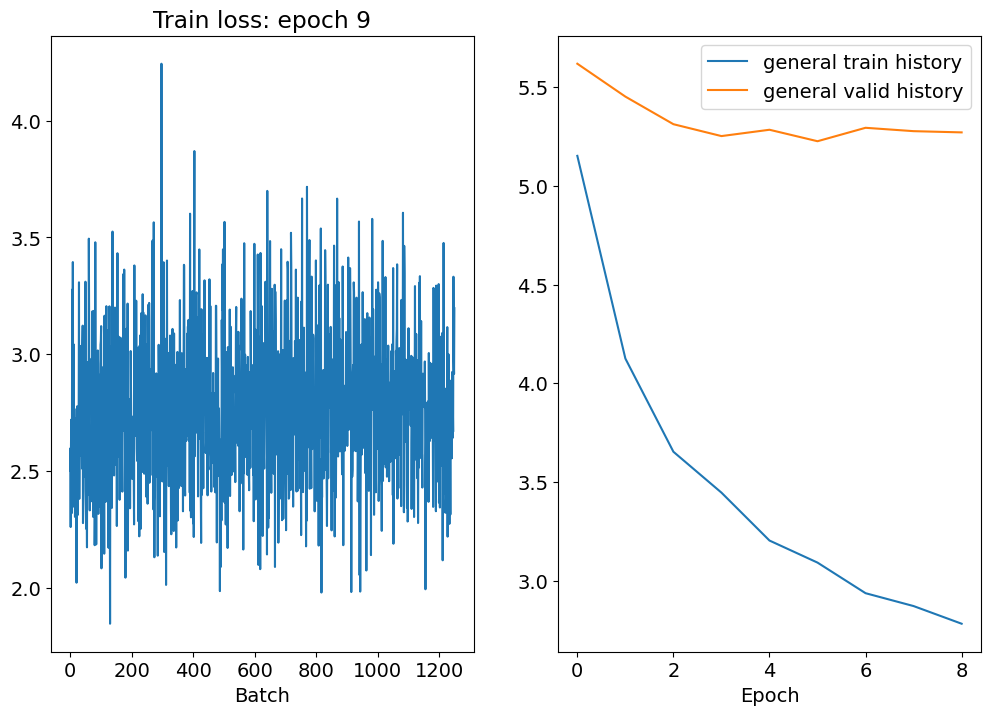

Epoch: 10 | Time: 8m 31s
	Train Loss: 2.764 | Train PPL:  15.864
	 Val. Loss: 5.287 |  Val. PPL: 197.800
{'BATCH_SIZE': 32, 'INPUT_DIM': 16000, 'OUTPUT_DIM': 16000, 'ENC_EMB_DIM': 256, 'DEC_EMB_DIM': 256, 'HID_DIM': 512, 'N_LAYERS': 2, 'ENC_DROPOUT': 0.3, 'DEC_DROPOUT': 0.3, 'PAD_IDX': 0, 'LR': 0.001, 'WEIGHT_DECAY': 1e-05, 'STEP_SIZE': 2, 'GAMMA': 0.5}


In [106]:
for epoch in range(N_EPOCHS):

    start_time = time.time()

    train_loss = train(model, train_dataloader, optimizer, criterion, CLIP, train_history, valid_history)
    valid_loss = evaluate(model, valid_dataloader, criterion)

    scheduler.step()

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'experiment3_model.pt')

    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

print(config)

#### Evaluation

In [107]:
test_model(model, test_iterator=test_dataloader, tokenizer=tokenizer, device=device, inverse_src=False)

=====Translation test=====
Original: Предоставляется постельное белье.
Target: Extras include bed linen and towels.
Generated: Bed linen is featured.
Original: Гости могут посетить ресторан гостевого дома, в котором подаются блюда восточной кухни.
Target: Guests are welcome to visit the on-site restaurant and taste Eastern cuisine.
Generated: Guests can enjoy the on-site restaurant serving traditional cuisine.


100%|██████████████████████████████████████████████████████████████████████████████████| 79/79 [00:11<00:00,  7.13it/s]


BLEU= 52.32


52.31544451044056

### Reference code

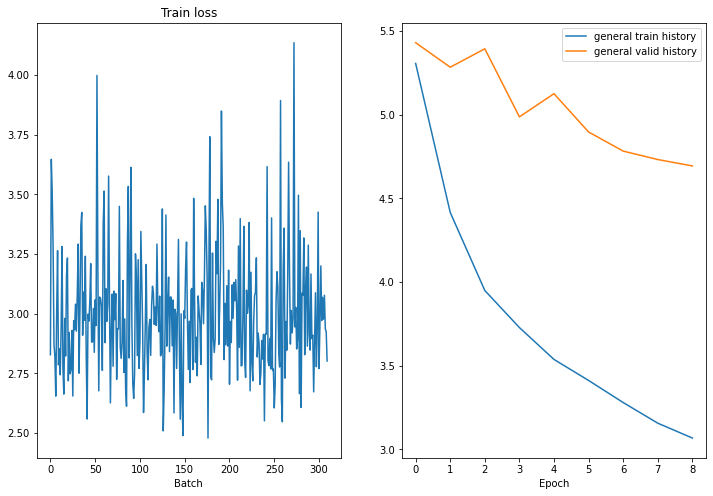

Epoch: 10 | Time: 1m 10s
	Train Loss: 2.998 | Train PPL:  20.040
	 Val. Loss: 4.710 |  Val. PPL: 111.007


In [ ]:
# ===============REFERENCE=================
# for epoch in range(N_EPOCHS):

#     start_time = time.time()

#     train_loss = train(model, train_iterator, optimizer, criterion, CLIP, train_history, valid_history)
#     valid_loss = evaluate(model, valid_iterator, criterion)

#     end_time = time.time()

#     epoch_mins, epoch_secs = epoch_time(start_time, end_time)

#     if valid_loss < best_valid_loss:
#         best_valid_loss = valid_loss
#         torch.save(model.state_dict(), 'tut1-model.pt')

#     train_history.append(train_loss)
#     valid_history.append(valid_loss)
#     print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
#     print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
#     print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

### Заключение
0) Во всех экспериментах использовался lr scheduler. Его параметры не сильно влияли на качество в экспериментах 1 и 2.
1) Эксперимент 1. Базовая модель + предобученный токенизатор (трансформерная модель Helsinki-NLP/opus-mt-ru-en). Получился слишком большой словарь (input_dim=62518), модель обучается очень долго. Остановлен после 5 эпох.
Параметры эксперимента:

> Epoch: 05 | Time: 14m 36s
	Train Loss: 3.395 | Train PPL:  29.801
	 Val. Loss: 6.645 |  Val. PPL: 768.660
{'BATCH_SIZE': 64, 'INPUT_DIM': 62520, 'OUTPUT_DIM': 62520, 'ENC_EMB_DIM': 256, 'DEC_EMB_DIM': 256, 'HID_DIM': 512, 'N_LAYERS': 2, 'ENC_DROPOUT': 0.3, 'DEC_DROPOUT': 0.3, 'PAD_IDX': 62517, 'LR': 0.001, 'WEIGHT_DECAY': 1e-05, 'STEP_SIZE': 4, 'GAMMA': 0.5}

> Translation test
> Original: Предоставляется постельное белье.
> 
> Target: Extras include bed linen and towels.
> 
> Generated: There is a private bathroom with a shower.
> 
> Original: Гости могут посетить ресторан гостевого дома, в котором подаются блюда восточной кухни.
> 
> Target: Guests are welcome to visit the on-site restaurant and taste Eastern cuisine.
> 
> Generated: There is a private bathroom with a shower.
> 
> BLEU= 8.37

В этом эксперименте при других запусках удавалось выбить метрику до 19.
    
3) Эксперимент 2. Базовая модель + SentencePiece токенизатор с ограниченным словарем (input_dim=16000). Результат с прямым порядком src дал результат лучше, чем с инвертированным. Параметры эксперимента:
   
> Epoch: 10 | Time: 5m 51s
        Train Loss: 3.728 | Train PPL:  41.607
         Val. Loss: 5.690 |  Val. PPL: 295.800
    {'BATCH_SIZE': 32, 'INPUT_DIM': 16000, 'OUTPUT_DIM': 16000, 'ENC_EMB_DIM': 256, 'DEC_EMB_DIM': 256, 'HID_DIM': 512, 'N_LAYERS': 2, 'ENC_DROPOUT': 0.3, 'DEC_DROPOUT': 0.3, 'PAD_IDX': 0, 'LR': 0.001, 'WEIGHT_DECAY': 1e-05, 'STEP_SIZE': 4, 'GAMMA': 0.5}
    
> Translation test
> Original: Предоставляется постельное белье.
> 
> Target: Extras include bed linen and towels.
> 
> Generated: Bed linen is available.
> 
> Original: Гости могут посетить ресторан гостевого дома, в котором подаются блюда восточной кухни.
> 
> Target: Guests are welcome to visit the on-site restaurant and taste Eastern cuisine.
> 
> Generated: The restaurant serves international cuisine and international cuisine.

> BLEU= 35.66
  
4) Эксперимент 3. Модель с attention + SentencePiece токенизатор с ограниченным словарем (input_dim=16000). В декодер добавлен Attention. Параметры эксперимента:

> Epoch: 10 | Time: 8m 31s
	Train Loss: 2.764 | Train PPL:  15.864
	 Val. Loss: 5.287 |  Val. PPL: 197.800
{'BATCH_SIZE': 32, 'INPUT_DIM': 16000, 'OUTPUT_DIM': 16000, 'ENC_EMB_DIM': 256, 'DEC_EMB_DIM': 256, 'HID_DIM': 512, 'N_LAYERS': 2, 'ENC_DROPOUT': 0.3, 'DEC_DROPOUT': 0.3, 'PAD_IDX': 0, 'LR': 0.001, 'WEIGHT_DECAY': 1e-05, 'STEP_SIZE': 2, 'GAMMA': 0.5}

> Translation test
> Original: Предоставляется постельное белье.
> 
> Target: Extras include bed linen and towels.
> 
> Generated: Bed linen is featured.
> 
> Original: Гости могут посетить ресторан гостевого дома, в котором подаются блюда восточной кухни.
> 
> Target: Guests are welcome to visit the on-site restaurant and taste Eastern cuisine.
> 
> Generated: Guests can enjoy the on-site restaurant serving traditional cuisine.
> 
> BLEU= 52.32


Итого: 
* attention дал значительный прирост качества;
* уменьшение стартового lr для базовой модели не давало  не давало прироста качества в экспериментах 1 и 2;
* увеличение dropout для базовой модели не давало прироста качества в экспериментах 1 и 2;
* обучение базовых моделей (эксперимент 1 и 2) было нестабильным: от запуска к запуску с одним и тем же конфигом метрика сильно плыла. Разброс был от примерно 6 до 35. Модель с attention стабильно выдавала BLEU на уровне 50.